In [20]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict() #可以将数据集名称的字符串映射到数据集相关的二元组上，这个二元组包含数据集的URL和验证文件完整性的sha-1密钥
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

In [21]:
def download(name, cache_dir=os.path.join('..', 'data')): #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}" #使用assert断言确保name存在于DATA_HUB

    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True) # 确保缓存目录存在

    fname = os.path.join(cache_dir, url.split('/')[-1]) # 构建本地文件名

    if os.path.exists(fname): # 如果文件已存在，校验其完整性
        sha1 = hashlib.sha1() # 创建SHA-1哈希对象

        with open(fname, 'rb') as f: # 以二进制只读模式打开文件
            while True:
                data = f.read(1048576) # 每次读取1MB数据
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname # 校验通过，返回文件名
        
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True) # 流式下载，适合大文件下载
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [22]:
def download_extract(name, folder=None): #@save
    """下载并解压zip/tar文件"""
    fname = download(name) # 下载文件并返回文件名
    base_dir = os.path.dirname(fname) # 获取文件名所在目录
    data_dir, ext = os.path.splitext(fname) # 获取文件名和扩展名
    if ext == ".zip":
        fp = zipfile.ZipFile(fname, "r")
    elif ext in (".tar", ".gz"):
        fp = tarfile.open(fname, "r")
    else:
        assert False, "只有zip/tar文件可以被解压缩"
    fp.extractall(base_dir) #解压文件到指定目录，与压缩文件同一个目录
    return os.path.join(base_dir, folder) if folder else data_dir 

def download_all(): #@save
    """下载DATA_HUB中的所有数据"""
    for name in DATA_HUB:
        download_extract(name)

In [23]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [24]:
DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [25]:
# 使用pandas读取数据集
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

In [26]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [27]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]]) #iloc是基于整数位置的索引，而loc是基于标签的索引

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [28]:
# 由于每个样本中都带有ID，但是这个ID对预测结果没有任何帮助，因此我们可以将其从数据中删除，就得到了最后的特征
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:])) # 合并训练集和测试集的特征，除了ID列

In [ ]:
# 首先对数据将进行预处理，将所有的缺失值替换为相应特征的均值，此外为了将所有特征放在一个共同的尺度上，我们将对所有特征进行标准化处理，这里将均值设为0，标准差设为1 x <- (x - mean(x)) / sd(x)

numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index

all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))

all_features[numeric_features] = all_features[numeric_features].fillna(0)


In [30]:
# 接下来处理离散值，也就是非数值型特征
# 我们使用独热编码将离散值转换为数值型特征
# 例如，假设我们有一个特征"颜色"，它有三个可能的值：红色、绿色和蓝色
# 我们可以将"颜色"特征转换为三个二进制特征："颜色_红色"、"颜色_绿色"和"颜色_蓝色"
# 如果一个样本的"颜色"是红色，那么"颜色_红色"为1，其他两个特征为0
# 如果一个样本的"颜色"是绿色，那么"颜色_绿色"为1，其他两个特征为0
# 如果一个样本的"颜色"是蓝色，那么"颜色_蓝色"为1，其他两个特征为0

all_features = pd.get_dummies(all_features, dummy_na=True)
print(all_features.shape)
print(all_features)

(2919, 331)
      MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0       0.067320    -0.184443 -0.217841     0.646073    -0.507197   1.046078   
1      -0.873466     0.458096 -0.072032    -0.063174     2.187904   0.154737   
2       0.067320    -0.055935  0.137173     0.646073    -0.507197   0.980053   
3       0.302516    -0.398622 -0.078371     0.646073    -0.507197  -1.859033   
4       0.067320     0.629439  0.518814     1.355319    -0.507197   0.947040   
...          ...          ...       ...          ...          ...        ...   
1454    2.419286    -2.069222 -1.043758    -1.481667     1.289537  -0.043338   
1455    2.419286    -2.069222 -1.049083    -1.481667    -0.507197  -0.043338   
1456   -0.873466     3.884968  1.246594    -0.772420     1.289537  -0.373465   
1457    0.655311    -0.312950  0.034599    -0.772420    -0.507197   0.682939   
1458    0.067320     0.201080 -0.068608     0.646073    -0.507197   0.715952   

      YearRemodAdd  MasVnrA

In [31]:
# 将所有特征转化为数值型特征后，我们可以将其转换为NumPy数组，后续转化成tensor
print(train_data.shape)
n_train = train_data.shape[0] # 训练集样本数

train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32) # 从特征矩阵中取前n_train行也就是训练集的特征，因为特征集是训练集和测试集的汇总

test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32) # 取出训练后的特征也就是测试集的

train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32) # 由于是预测房价，所以最后的标签集是SalePrice，使用values取出来并转换为NumPy数组，再reshape成列向量

(1460, 81)


In [ ]:
# 训练，首先会选择使用最基础的模型也就是线性模型来训练，如果结果和随机猜测的结果一样，那很可能是数据处理错误。其次使用最简单的模型来作为一个基准线提醒以后的模型必须要超过这个基准线才能被接受。最后就是说不定数据本身就有问题，使用简单模型先试探减少成本。
loss = nn.MSELoss()
in_features = train_features.shape[1] # 输入特征数，也就是输入层的神经元数

def get_net():
    net = nn.Sequential(
        nn.Linear(in_features, 1)
        )
    return net

In [33]:
# 在房价预测等场景时，往往会出现价格的绝对值高低相差悬殊，这时候的损失函数就不能单纯的使用均方误差，需要考虑相对误差
# 例如，我们预测的偏差是10w，但是两个样本的真实值分别是12w和1000w。

In [34]:
# 对数均方差（Log RMSE）
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf')) # 对预测值进行截断，确保值在1到正无穷之间，由于对数的自变量不能为0或负数，而当自变量在0-1之间时，对数值会变得很不稳定，可能自变量相差一点，但是数值却相差很多，平方之后会更多，所以取值要大于1因为房价不会为0，所以也不能取0
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))

    return rmse.item()

In [35]:
def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], [] # 训练集和测试集的误差
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用Adam优化算法，自适应学习率算法，比SGD更稳定，而且对学习率更不敏感
    optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad() # 梯度清零，因为pytorch会累加梯度，所以每次迭代需要清零
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        train_ls.append(log_rmse(net, train_features, train_labels))

        if test_labels is not None: #跳过没有测试标签的情况
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [39]:
# 接下来我们要初始化超参数，这里利用K折交叉验证来选择超参数
def get_k_fold_data(k, i, X, y):
    """
    获取第i折交叉验证时的训练集和验证集
    """

    assert k > 1 # 至少要有2折交叉验证
    fold_size = X.shape[0] // k # 每折的样本数
    X_train, y_train = None, None # 训练集和标签
    
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size) # 第j折的索引
        X_part, y_part = X[idx, :], y[idx] # 第j折的数据集和标签

        if j == i: # 第i折为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None: # 第1折为训练集
            X_train, y_train = X_part, y_part
        else: # 其他折为训练集
            X_train = torch.cat([X_train, X_part], dim=0) # 指定维度拼接，也就是说找到了验证集，剩下的都是训练集要拼接一起
            y_train = torch.cat([y_train, y_part], dim=0)
    return X_train, y_train, X_valid, y_valid


In [40]:
# 如何划分训练集已经写好了，接下来是如何进行训练
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    """
    K折交叉验证
    """
    train_l_sum, valid_l_sum = 0, 0 # 训练集和验证集的损失和

    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1] # 最后一个epoch的损失
        valid_l_sum += valid_ls[-1] # 最后一个epoch的损失
        
        # 由于绘图很浪费时间，所以只绘制第1折的训练集和验证集损失，毕竟其他的图也差不多
        if i == 0: # 第1折的训练集和验证集损失
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls], xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs], legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse {float(train_ls[-1]):f}, 验证log rmse {float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k # 返回平均训练集和验证集的损失

折1，训练log rmse 0.171126, 验证log rmse 0.156869
折2，训练log rmse 0.162384, 验证log rmse 0.192971
折3，训练log rmse 0.164102, 验证log rmse 0.168709
折4，训练log rmse 0.168209, 验证log rmse 0.154535
折5，训练log rmse 0.163818, 验证log rmse 0.182944
5-折验证: 平均训练log rmse 0.165928, 平均验证log rmse 0.171205


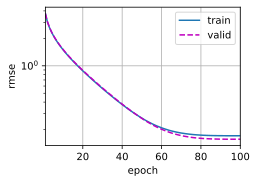

In [41]:
# 这里我们先初始化一组超参数，然后用K折交叉验证来验证这组超参数的有效性，最后再慢慢调优
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse {float(train_l):f}, 平均验证log rmse {float(valid_l):f}')


In [ ]:
# 经过K折交叉验证，我们可以选择出一组最优的超参数,接着就可以对训练集进行训练，然后应用于测试集，最后将预测保存在CSV文件中上传

def train_and_pred(train_features, train_labels, test_features, test_labels, num_epochs, lr, weight_decay, batch_size):
    """
    训练模型并预测测试集
    """
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None, num_epochs, lr, weight_decay, batch_size)

    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs], legend=['train'], yscale='log')
    print(f'训练log rmse: {float(train_ls[-1]):f}')
    # 将模型应用于测试集进行预测
    preds = net(test_features).detach().numpy()
    # 格式化并导出
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)


In [ ]:
train_and_pred(train_features, train_labels, test_features, test_labels, num_epochs, lr, weight_decay, batch_size)
